# ORM Jacobian — CFD Orbit Feedback (ALBA-II)

Validates the analytical formulas when changing combined-function dipoles (CFDs)
with active orbit and frequency feedback (Cor_SVD). Each CFD is perturbed in both
its quadrupole (K1) and dipole (K0) components maintaining the CFD geometry ratio.

Quantities compared:
- **ORM Jacobian** dR/dK_CFD (horizontal and vertical)
- **Dispersion change at sextupoles** dη/dK_CFD
- **Energy change** d(dp/p)/dK_CFD — numerical vs `dCFD_denergy` analytical formula
- **Corrector kicks** dkicks/dK_CFD — numerical vs analytical SVD prediction
- **Orbit at sextupoles** dx_sex/dK_CFD — numerical vs η·dE + R(sex,cor)·kicks

Tensor convention: axis 0 = CFD, axis 1 = BPM, axis 2 = corrector.

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("../scripts")))

from general_numerical import NumericalCalculation
from ACalORAT import AnaORM, plot_utils, math_utils, numerical

## Parameters

In [2]:
calc = NumericalCalculation("ring_a2", {
    "direction" : "both",
    "elements"  : "CFD",
    "feedback"  : "Cor_SVD",
    "linearize" : -1,
    "fringes"   : True,
    "dispersion": True,
    "step"      : 1e-5,
}, root=Path("../"))

calc.compute()

Found existing case 3 matching parameters.
Loading cached results for case 3.


## Analytical — ORM Jacobian

Total = quadrupole term + dipole dispersion term + residual energy term.
After Full_SVD feedback the residual energy is ≈ 0, so the energy term is small.

In [3]:
ring, ind = calc.ring, calc.ind

# Semi-numerical dORM/dEnergy (shape n_BPM x n_cor)
dRij_dE = numerical.quickdORMdEnergy(ring, ind)

# Results from numerical feedback simulation
energy = calc.results["energy"]   # (n_CFD,) residual dp/p after feedback, ≈ 0 for Cor_SVD
x_sex  = calc.results["x_sex"]    # (n_CFD, n_sex) orbit at sextupoles after feedback

K2_sex = np.array([ring[i].PolynomB[2] for i in ind["sex"]])  # (n_sex,)

# --- VERTICAL ---
cORM_v = AnaORM.AnaORM(ring, "v", ind)
cORM_v.assign_optics()

# K1 term (quad component of CFD)
ana_v  = cORM_v.dRij_dqk_thick23(cORM_v.bpm, cORM_v.cor, cORM_v.CFD)

# Residual energy term (≈ 0 after Cor_SVD, kept for completeness)
ana_v += cORM_v.dRij_dk_energy_term(cORM_v.bpm, cORM_v.cor, cORM_v.CFD, dRij_dE["v"], energy)

# Sextupole orbit term: feedback leaves residual orbit x_sex at sextupoles
# -> effective DeltaK1_sex = K2_sex * x_sex (PolynomB[1] convention, same sign both planes)
cORM_v.sex.broadcasters(0, 3)
cORM_v.bpm.broadcasters(1, 3)
cORM_v.cor.broadcasters(2, 3)
dR_dK1_sex_v = cORM_v.dRij_dqk_thick23(cORM_v.bpm, cORM_v.cor, cORM_v.sex)  # (n_sex, n_bpm, n_cor_v)
ana_v += np.einsum("sij,ks->kij", dR_dK1_sex_v, K2_sex * x_sex)

# --- HORIZONTAL ---
cORM_h = AnaORM.AnaORM(ring, "h", ind)
cORM_h.assign_optics()

# K1 term + bending (K0) dispersion term
ana_h  = cORM_h.dRij_dqk_thick23(cORM_h.bpm, cORM_h.cor, cORM_h.CFD)
ana_h += cORM_h.dRij_dbend_thick23_disp(cORM_h.bpm, cORM_h.cor, cORM_h.CFD)

# Residual energy term
ana_h += cORM_h.dRij_dk_energy_term(cORM_h.bpm, cORM_h.cor, cORM_h.CFD, dRij_dE["h"], energy)

# Sextupole orbit term (same PolynomB[1] convention -> same einsum sign as vertical)
cORM_h.sex.broadcasters(0, 3)
cORM_h.bpm.broadcasters(1, 3)
cORM_h.cor.broadcasters(2, 3)
dR_dK1_sex_h = cORM_h.dRij_dqk_thick23(cORM_h.bpm, cORM_h.cor, cORM_h.sex)  # (n_sex, n_bpm, n_cor_h)
ana_h += np.einsum("sij,ks->kij", dR_dK1_sex_h, K2_sex * x_sex)

## Results — ORM Jacobian

Vertical   nRMSE per CFD (mean): 83.35%
Horizontal nRMSE per CFD (mean): 55.19%


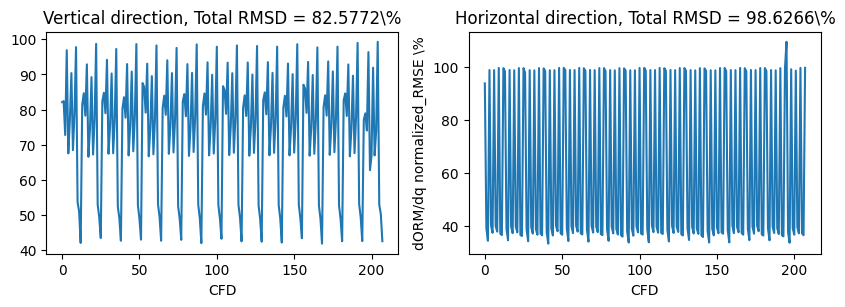

In [4]:
num_v = calc.numerical("v")
num_h = calc.numerical("h")

err_v = math_utils.normalized_RMSE(num_v, ana_v, dims=(1, 2))
err_h = math_utils.normalized_RMSE(num_h, ana_h, dims=(1, 2))
print(f"Vertical   nRMSE per CFD (mean): {err_v.mean():.2f}%")
print(f"Horizontal nRMSE per CFD (mean): {err_h.mean():.2f}%")

plot_utils.plot_both_Zeus(num_v, num_h, ana_v, ana_h, xlabel="CFD")

## Analytical — Dispersion Change at Sextupoles

Change in the horizontal dispersion function η at sextupole positions when varying
each CFD. `dni_dqk_integral` evaluated at sextupoles includes the bending source
term `B0/(L·K1)` for CFDs.

Output `(n_sex, n_CFD)` → transposed to `(n_CFD, n_sex)` to match `ddisp`.

In [5]:
# Reset broadcasters for 2D computation (CFD was left at ndim=3 from ORM Jacobian call)
cORM_h.sex.broadcasters(0, 2)
cORM_h.CFD.broadcasters(1, 2)
ana_disp = cORM_h.dni_dqk_integral(cORM_h.sex, cORM_h.CFD).T  # (n_CFD, n_sex)

## Results — Dispersion Change at Sextupoles

Dispersion nRMSE per CFD (mean): 47.70%


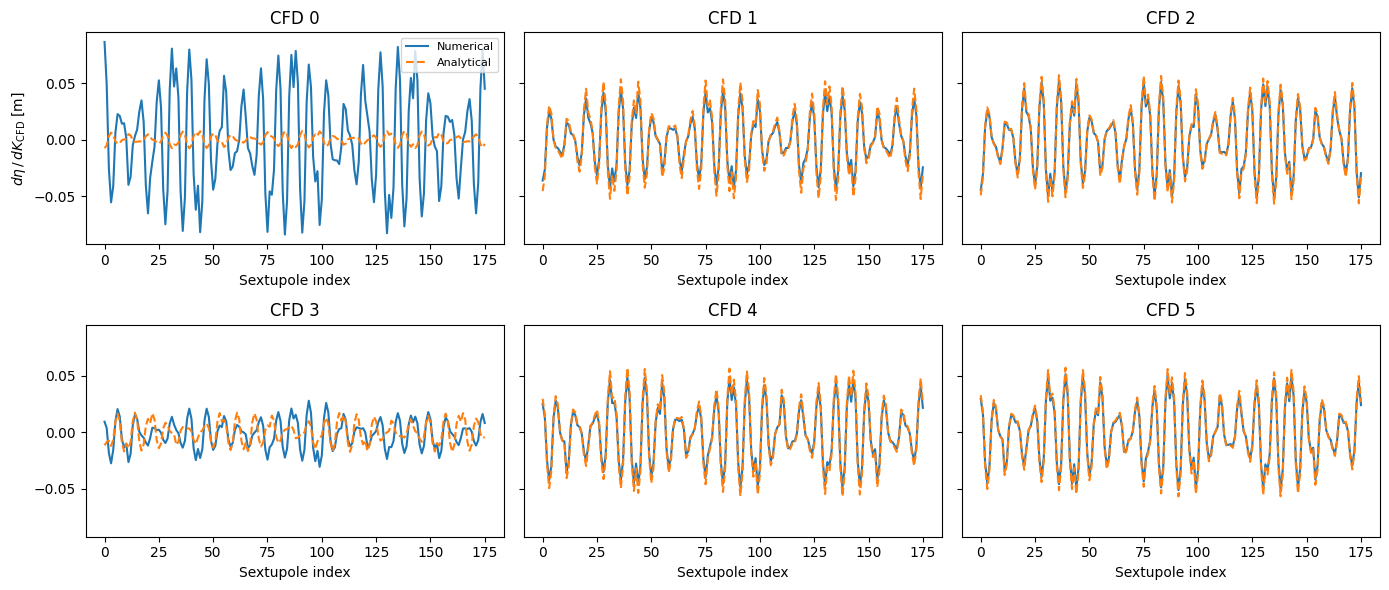

In [6]:
num_disp = calc.results["ddisp"]  # (n_CFD, n_sex) — dispersion change at sextupoles

err_disp = math_utils.normalized_RMSE(num_disp, ana_disp, dims=(1,))
print(f"Dispersion nRMSE per CFD (mean): {err_disp.mean():.2f}%")

n_show = min(6, num_disp.shape[0])
fig, axes = plt.subplots(2, 3, figsize=(14, 6), sharey=True)
axes = axes.ravel()
for ax, k in zip(axes, range(n_show)):
    ax.plot(num_disp[k],     label="Numerical")
    ax.plot(ana_disp[k], "--", label="Analytical")
    ax.set_title(f"CFD {k}")
    ax.set_xlabel("Sextupole index")
axes[0].set_ylabel(r"$d\eta\,/\,dK_\mathrm{CFD}$ [m]")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

## Energy Change per CFD — Analytical vs Numerical

`dCFD_denergy` analytically predicts the dp/p shift per unit K₁ step caused by
perturbing the K0 component of each CFD with the Cor_SVD feedback active.
The formula accounts for corrector kicks holding the BPM orbit and the RF frequency
adjustment that prevents corrector drift.

Energy nRMSE: 0.86+0.00j%


/Users/deumenec/ATcollab/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/deumenec/ATcollab/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


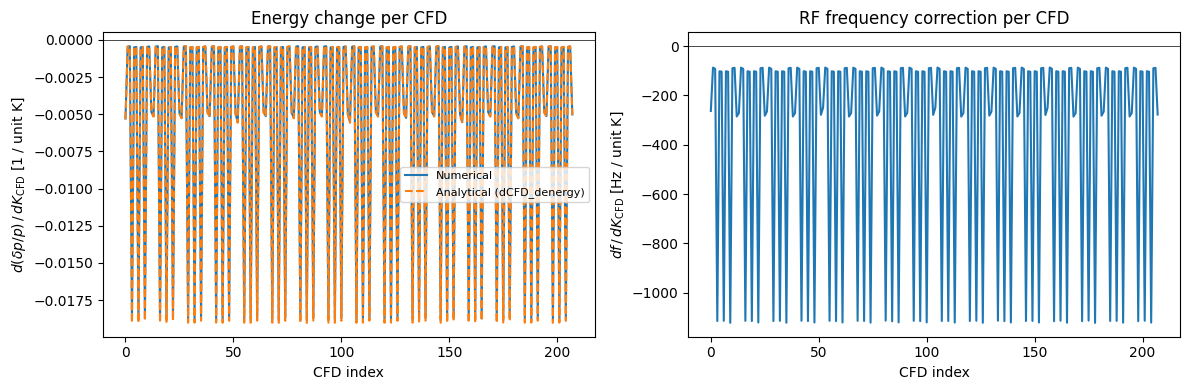

In [7]:
energy = calc.results["energy"]   # (n_CFD,) dp/p per unit K after Cor_SVD feedback
dfreq  = calc.results["dfreq"]    # (n_CFD,) Hz/unit K — RF correction applied by feedback

mcf = numerical.get_mcf(ring)
f0  = ring.get_rf_frequency()
dE_compensated = dfreq / (mcf * f0)  # dp/p equivalent of RF correction (reused in sext-orbit)

# Analytical energy change: dCFD_denergy accounts for orbit-corrector effect + RF adjustment
# Reset to 2D broadcasting (bpm and CFD were left at ndim=3 from ORM Jacobian cell)
cORM_h.bpm.broadcasters(0, 2)
cORM_h.cor.broadcasters(1, 2)
# cORM_h.CFD is already at axis 1, ndim=2 from analytical-disp cell
ana_energy = cORM_h.dCFD_denergy(cORM_h.bpm, cORM_h.cor, cORM_h.CFD)

err_energy = math_utils.normalized_RMSE(energy, ana_energy, dims=(0,))
print(f"Energy nRMSE: {err_energy:.2f}%")

cfd_idx = np.arange(len(energy))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(cfd_idx, energy,     label="Numerical")
axes[0].plot(cfd_idx, ana_energy, "--", label="Analytical (dCFD_denergy)")
axes[0].set_xlabel("CFD index")
axes[0].set_ylabel(r"$d(\delta p/p)\,/\,dK_\mathrm{CFD}$ [1 / unit K]")
axes[0].set_title("Energy change per CFD")
axes[0].axhline(0, color="k", lw=0.5)
axes[0].legend(fontsize=8)

axes[1].plot(cfd_idx, dfreq)
axes[1].set_xlabel("CFD index")
axes[1].set_ylabel(r"$df\,/\,dK_\mathrm{CFD}$ [Hz / unit K]")
axes[1].set_title("RF frequency correction per CFD")
axes[1].axhline(0, color="k", lw=0.5)

plt.tight_layout()
plt.show()

## Corrector Kicks Applied by Feedback — Analytical vs Numerical

`dkicksdCFDk(bpm, cor, CFD)` predicts the horizontal corrector kicks applied by
the Cor_SVD feedback to first order: `dθ = pinv(R_bpm_cor) · R(bpm, CFD) · (Bend/K_eff)`.
Vertical kicks are ≈ 0 (no first-order vertical orbit from horizontal bending).

H kicks nRMSE per CFD (mean): 0.35%
V/H kick norm ratio   (mean): 0.00%


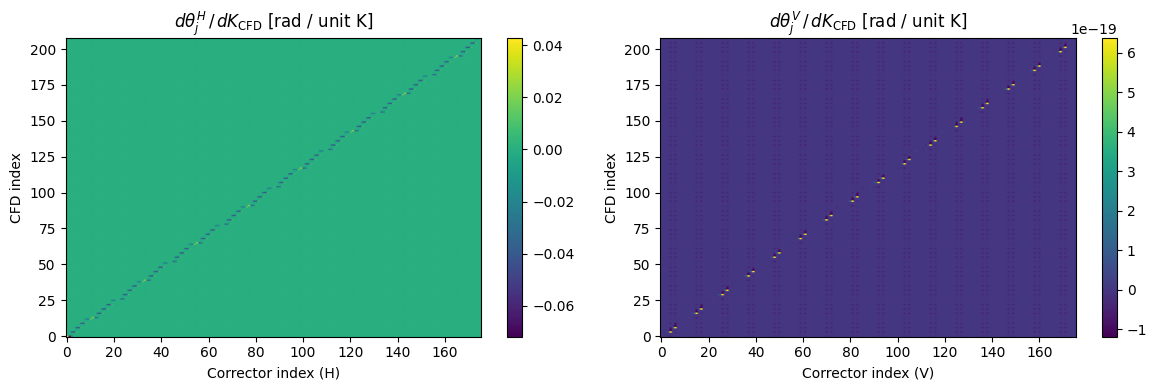

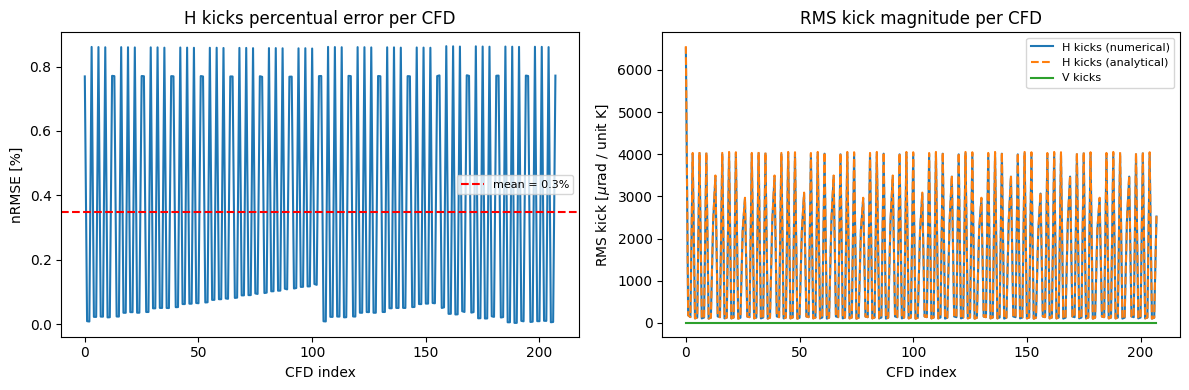

[[ 4.29193228e-02 -7.23580375e-02 -2.20419799e-02 ...  3.09073542e-05
   1.99048322e-04 -6.16403391e-04]
 [ 7.34271271e-04 -1.23769101e-03 -1.88683951e-03 ...  2.64685804e-06
   1.70461907e-05 -1.87011414e-05]
 [ 2.01081244e-04 -3.38759503e-04 -1.76249456e-03 ...  2.47261232e-06
   1.59240203e-05 -1.18510270e-05]
 ...
 [-2.39656123e-05  4.38959654e-05  2.41490083e-05 ... -9.16962278e-04
   2.13564080e-04 -1.27407322e-04]
 [-2.08474850e-05  4.08069632e-05  2.24496189e-05 ... -1.54590079e-03
   3.46225258e-04 -2.06758472e-04]
 [-4.93142220e-04  4.68234231e-04  2.57595254e-04 ... -2.14536040e-02
  -2.22230194e-02  1.32923384e-02]]
[[ 4.25917402e-02 -7.18055953e-02 -2.18726487e-02 ...  3.06811956e-05
   1.97597846e-04 -6.11745547e-04]
 [ 7.34344773e-04 -1.23781204e-03 -1.88699406e-03 ...  2.64694490e-06
   1.70472686e-05 -1.87027134e-05]
 [ 2.01100906e-04 -3.38791843e-04 -1.76262980e-03 ...  2.47278702e-06
   1.59256298e-05 -1.18522185e-05]
 ...
 [-2.39708044e-05  4.39047545e-05  2.4153461

In [8]:
dkicks_h = calc.results["dkicks_h"]  # (n_CFD, n_cor_h)
dkicks_v = calc.results["dkicks_v"]  # (n_CFD, n_cor_v)

# Analytical horizontal kicks via dkicksdCFDk (3D broadcasting: bpm=0, cor=1, CFD=2)
cORM_h.bpm.broadcasters(0, 3)
cORM_h.cor.broadcasters(1, 3)
cORM_h.CFD.broadcasters(2, 3)
ana_kicks_h = cORM_h.dkicksdCFDk(cORM_h.bpm, cORM_h.cor, cORM_h.CFD)  # (n_CFD, n_cor_h)

# --- Percentual error ---
err_h = math_utils.normalized_RMSE(dkicks_h, ana_kicks_h, dims=(1,))  # (n_CFD,)
norm_h = np.sqrt(np.mean(dkicks_h**2, axis=1))
norm_v = np.sqrt(np.mean(dkicks_v**2, axis=1))
print(f"H kicks nRMSE per CFD (mean): {err_h.mean():.2f}%")
print(f"V/H kick norm ratio   (mean): {np.mean(norm_v / (norm_h + 1e-30)):.2%}")

# --- Kick matrices ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
im_h = axes[0].imshow(dkicks_h, aspect="auto", origin="lower")
axes[0].set_xlabel("Corrector index (H)")
axes[0].set_ylabel("CFD index")
axes[0].set_title(r"$d\theta_j^H\,/\,dK_\mathrm{CFD}$ [rad / unit K]")
plt.colorbar(im_h, ax=axes[0])

im_v = axes[1].imshow(dkicks_v, aspect="auto", origin="lower")
axes[1].set_xlabel("Corrector index (V)")
axes[1].set_ylabel("CFD index")
axes[1].set_title(r"$d\theta_j^V\,/\,dK_\mathrm{CFD}$ [rad / unit K]")
plt.colorbar(im_v, ax=axes[1])
plt.tight_layout()
plt.show()

# --- Percentual error + kick norms ---
cfd_idx = np.arange(len(err_h))
fig2, axes2 = plt.subplots(1, 2, figsize=(12, 4))

axes2[0].plot(cfd_idx, err_h)
axes2[0].axhline(err_h.mean(), color="r", ls="--", label=f"mean = {err_h.mean():.1f}%")
axes2[0].set_xlabel("CFD index")
axes2[0].set_ylabel("nRMSE [%]")
axes2[0].set_title("H kicks percentual error per CFD")
axes2[0].legend(fontsize=8)

axes2[1].plot(cfd_idx, norm_h * 1e6, label="H kicks (numerical)")
axes2[1].plot(cfd_idx, np.sqrt(np.mean(ana_kicks_h**2, axis=1)) * 1e6, "--", label="H kicks (analytical)")
axes2[1].plot(cfd_idx, norm_v * 1e6, label="V kicks")
axes2[1].set_xlabel("CFD index")
axes2[1].set_ylabel(r"RMS kick [$\mu$rad / unit K]")
axes2[1].set_title("RMS kick magnitude per CFD")
axes2[1].legend(fontsize=8)

plt.tight_layout()
plt.show()
print(ana_kicks_h)
print(dkicks_h)

## Orbit at Sextupoles — Analytical vs Numerical

`dxldCFDk(bpm, cor, CFD, sex)` analytically predicts the horizontal closed-orbit
displacement at each sextupole when a CFD is perturbed, accounting for:
- The direct orbit response from the K0 bending change
- The Cor_SVD orbit correction (SVD kicks that hold BPM orbit)
- The RF frequency adjustment (energy + dispersion term)

Output shape: `(n_CFD, n_sex)`.

x_sex nRMSE per CFD (mean): 0.35%


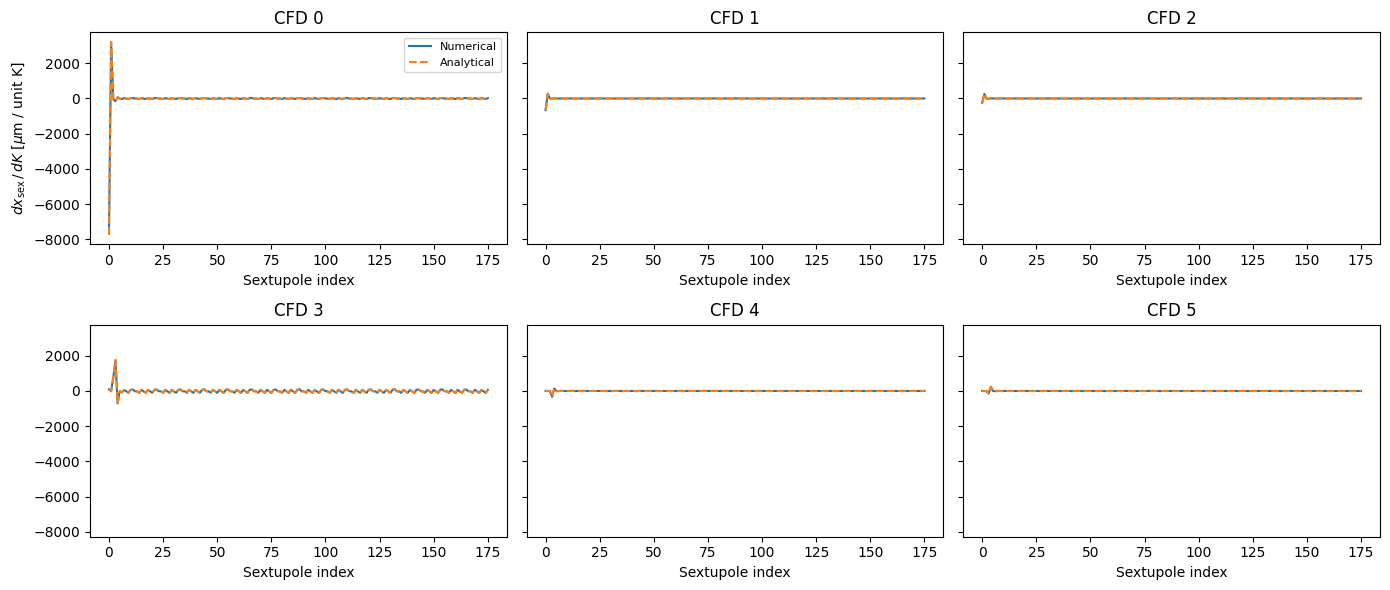

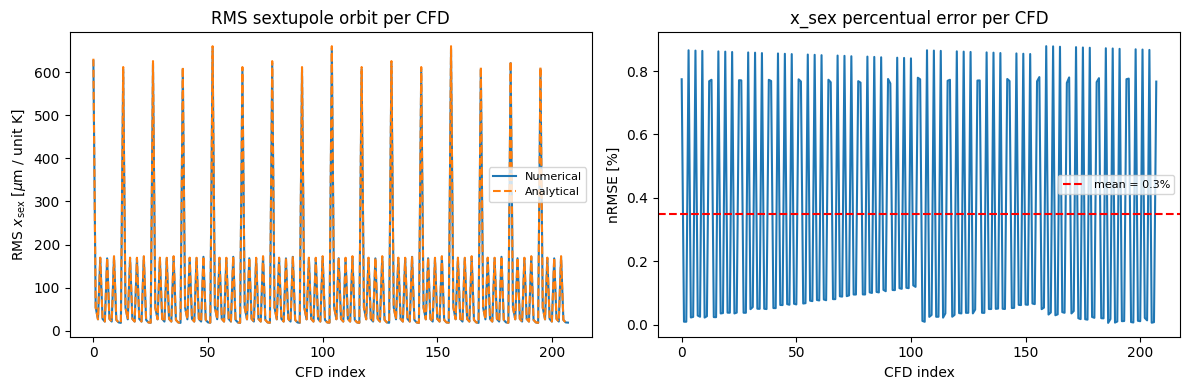

In [9]:
x_sex  = calc.results["x_sex"]   # (n_CFD, n_sex) — numerical horizontal orbit at sextupoles
dx_sex = calc.results["dx_sex"]  # (n_CFD, n_sex) — numerical slope at sextupoles

# Analytical orbit at sextupoles using the validated dxldCFDk formula
# Broadcasting convention: bpm(0,4), cor(1,4), CFD(2,4), sex(3,4)
cORM_h.bpm.broadcasters(0, 4)
cORM_h.cor.broadcasters(1, 4)
cORM_h.CFD.broadcasters(2, 4)
cORM_h.sex.broadcasters(3, 4)
ana_x_sex = cORM_h.dxldCFDk(cORM_h.bpm, cORM_h.cor, cORM_h.CFD, cORM_h.sex)  # (n_CFD, n_sex)

err_sex = math_utils.normalized_RMSE(x_sex, ana_x_sex, dims=(1,))
print(f"x_sex nRMSE per CFD (mean): {err_sex.mean():.2f}%")

# --- Per-CFD comparison plots ---
n_show = min(6, x_sex.shape[0])
fig, axes = plt.subplots(2, 3, figsize=(14, 6), sharey=True)
axes = axes.ravel()
for ax, k in zip(axes, range(n_show)):
    ax.plot(x_sex[k] * 1e6,     label="Numerical")
    ax.plot(ana_x_sex[k] * 1e6, "--", label="Analytical")
    ax.set_title(f"CFD {k}")
    ax.set_xlabel("Sextupole index")
axes[0].set_ylabel(r"$dx_\mathrm{sex}\,/\,dK$ [$\mu$m / unit K]")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

# --- RMS summary + percentual error ---
rms_sex_num = np.sqrt(np.mean(x_sex**2,     axis=1))
rms_sex_ana = np.sqrt(np.mean(ana_x_sex**2, axis=1))
cfd_idx = np.arange(len(err_sex))

fig2, axes2 = plt.subplots(1, 2, figsize=(12, 4))
axes2[0].plot(rms_sex_num * 1e6, label="Numerical")
axes2[0].plot(rms_sex_ana * 1e6, "--", label="Analytical")
axes2[0].set_xlabel("CFD index")
axes2[0].set_ylabel(r"RMS $x_\mathrm{sex}$ [$\mu$m / unit K]")
axes2[0].set_title("RMS sextupole orbit per CFD")
axes2[0].legend(fontsize=8)

axes2[1].plot(cfd_idx, err_sex)
axes2[1].axhline(err_sex.mean(), color="r", ls="--", label=f"mean = {err_sex.mean():.1f}%")
axes2[1].set_xlabel("CFD index")
axes2[1].set_ylabel("nRMSE [%]")
axes2[1].set_title("x_sex percentual error per CFD")
axes2[1].legend(fontsize=8)

plt.tight_layout()
plt.show()